# Task A2 — Rule Impact Analysis
Reconstructs what each rule actually did (or didn't do) and estimates dollar impact.
Covers: A2 (rule impact), A3 (bad decisions), A4 (revenue delay).

In [1]:
# --- Setup: load and clean all tables (compact — see explore_data.ipynb for full reasoning) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

DATA_DIR = r'c:\Users\typal\Downloads\mine-data-task-TP'
sns.set_theme(style='whitegrid', palette='muted')

# --- Performance ---
perf = pd.read_csv(f'{DATA_DIR}/daily_adset_performance.csv')
perf['date'] = pd.to_datetime(perf['date'])
perf['adset_id'] = perf['adset_id'].astype(str)
perf['is_zero_spend'] = perf['spend'] == 0
for col in ['revenue', 'profit', 'estimated_conversions']:
    perf.loc[perf['is_zero_spend'], col] = perf.loc[perf['is_zero_spend'], col].fillna(0)

# --- Rule executions ---
execs = pd.read_csv(f'{DATA_DIR}/rule_executions.csv')
execs['adset_id'] = execs['adset_id'].astype(str)
execs['action_date'] = pd.to_datetime(execs['action_date'])
execs['action_time'] = pd.to_datetime(execs['action_time'], utc=True, errors='coerce')
execs['api_success'] = execs['response'].str.strip().str.upper() == 'SUCCESS'
execs['action_type'] = execs['action_name'].apply(
    lambda n: 'Turn OFF' if 'OFF' in str(n).upper()
    else ('Turn ON' if 'ON' in str(n).upper()
    else ('Budget Decrease' if 'DECREASE' in str(n).upper() else 'other'))
)

# First successful fire per adset+date+rule (deduped)
execs_dedup = (
    execs[execs['api_success']]
    .sort_values('action_time')
    .drop_duplicates(subset=['adset_id', 'action_date', 'rule_id'], keep='first')
    .copy()
)

# --- Rules reference ---
rules = pd.read_csv(f'{DATA_DIR}/auto_rules.csv')

print(f'Ready. perf={perf.shape}, execs_dedup={execs_dedup.shape}, rules={rules.shape}')
print(f'Action types in deduped execs: {execs_dedup["action_type"].value_counts().to_dict()}')

Ready. perf=(4947, 19), execs_dedup=(80, 29), rules=(12, 6)
Action types in deduped execs: {'Turn OFF': 68, 'Budget Decrease': 12}


---
## Section 1 — A2: Rule Impact
**Counterfactual assumption (stated explicitly):** if a rule had NOT fired, the adset would have continued spending at the same daily budget and earning the same daily ROI it had on the day *before* the action. This is a lower-bound estimate — real revenue might have grown or shrunk. We label this assumption throughout.

In [5]:
# --- Join deduped executions to performance on action day ---
# We need daily metrics at the moment the rule fired.
joined = execs_dedup.merge(
    perf[['adset_id', 'date', 'spend', 'revenue', 'profit', 'roi', 'spend_day_no']],
    left_on=['adset_id', 'action_date'],
    right_on=['adset_id', 'date'],
    how='left',
    suffixes=('', '_perf')
)

print(f'Joined rows: {len(joined)} (should be {len(execs_dedup)} — no rows dropped)')
print(f'Nulls in spend after join: {joined["spend"].isna().sum()}')
joined['today_roi_at_action'] = joined['roi']
print(f'\nAction types in joined set:')
print(joined['action_type'].value_counts())

Joined rows: 80 (should be 80 — no rows dropped)
Nulls in spend after join: 0

Action types in joined set:
action_type
Turn OFF           68
Budget Decrease    12
Name: count, dtype: int64


In [10]:
# --- Build a "next-day" lookup: for each adset, what was profit/spend on day D+1, D+2? ---
# We'll use this for Turn OFF impact (what did the rule prevent the adset from earning?).
perf_indexed = (
    perf.drop_duplicates(subset=['adset_id', 'date'])
    .set_index(['adset_id', 'date'])[['spend', 'profit', 'roi']]
)

def get_next_day_profit(adset_id, action_date, days_ahead=1):
    target = action_date + pd.Timedelta(days=days_ahead)
    try:
        val = perf_indexed.loc[(adset_id, target), 'profit']
        return val.iloc[0] if isinstance(val, pd.Series) else val
    except KeyError:
        return np.nan

def get_prev_day_roi(adset_id, action_date):
    target = action_date - pd.Timedelta(days=1)
    try:
        val = perf_indexed.loc[(adset_id, target), 'roi']
        return val.iloc[0] if isinstance(val, pd.Series) else val
    except KeyError:
        return np.nan

print('Lookup functions defined.')
print(f'perf_indexed shape: {perf_indexed.shape}')

Lookup functions defined.
perf_indexed shape: (4875, 3)


In [13]:
result = turnoff.apply(
    lambda r: get_next_day_profit(r['adset_id'], r['action_date'], 1), axis=1
)
print(type(result))
print(result.head())

<class 'pandas.core.series.Series'>
0    0.0
1    0.0
2    0.0
3    0.0
5    0.0
dtype: float64


> **Fixes applied before this cell:**
> - Deduplicated `perf` on `(adset_id, date)` before building the lookup index (72 duplicate rows found)
> - Added `.iloc[0]` guard in `get_next_day_profit` / `get_prev_day_roi` to handle multi-row index hits
> - Added `reset_index(drop=True)` to `turnoff` to prevent Series/DataFrame mismatch on column assignment

In [14]:
# --- TURN OFF impact analysis ---
#
# For each Turn OFF execution:
#   - Counterfactual spend = same as action day's spend
#   - Counterfactual profit = counterfactual_spend * prev_day_roi
#   - Actual D+1 profit = what the adset actually earned next day (0 if paused)
#   - Impact = counterfactual_profit (what was blocked)
#     If counterfactual_profit > 0: rule BURNED money (blocked a winning adset)
#     If counterfactual_profit < 0: rule SAVED money (correctly blocked a loser)
#
# We look at D+1 only (one day forward). The adset may have been re-enabled,
# so we also check actual D+1 spend to see if it was actually paused.

turnoff = joined[joined['action_type'] == 'Turn OFF'].copy().reset_index(drop=True)

turnoff['prev_roi'] = turnoff.apply(
    lambda r: get_prev_day_roi(r['adset_id'], r['action_date']), axis=1
)

turnoff['baseline_roi'] = turnoff['prev_roi'].fillna(turnoff['roi'])
turnoff['counterfactual_profit'] = turnoff['spend'] * turnoff['baseline_roi']

turnoff['actual_d1_profit'] = turnoff.apply(
    lambda r: get_next_day_profit(r['adset_id'], r['action_date'], 1), axis=1
)

turnoff['dollar_saved'] = turnoff['counterfactual_profit'].apply(lambda x: -x if x < 0 else 0)
turnoff['dollar_burned'] = turnoff['counterfactual_profit'].apply(lambda x: x if x > 0 else 0)

print(f'Turn OFF rows: {len(turnoff)}')
print(f'  Correct pauses (saved $):   {(turnoff["dollar_saved"] > 0).sum()}')
print(f'  Mistaken pauses (burned $): {(turnoff["dollar_burned"] > 0).sum()}')
print(f'  Total estimated $ saved:  ${turnoff["dollar_saved"].sum():.2f}')
print(f'  Total estimated $ burned: ${turnoff["dollar_burned"].sum():.2f}')
print(f'  Net impact:               ${turnoff["dollar_saved"].sum() - turnoff["dollar_burned"].sum():.2f}')

Turn OFF rows: 68
  Correct pauses (saved $):   52
  Mistaken pauses (burned $): 6
  Total estimated $ saved:  $35.74
  Total estimated $ burned: $13.21
  Net impact:               $22.52


In [15]:
# --- BUDGET DECREASE impact analysis ---
#
# For each Budget Decrease execution:
#   - Budget cut % = (old_budget - new_budget) / old_budget
#   - Foregone spend = spend * cut_pct  (counterfactual: would have spent that extra amount)
#   - Foregone revenue = foregone_spend * (revenue / spend) on action day, if ROI > 0
#   - Foregone profit  = foregone_spend * today_roi_at_action, if ROI > 0
#   - If ROI < 0: the cut SAVED money = foregone_spend * abs(today_roi_at_action)

budgetdec = joined[joined['action_type'] == 'Budget Decrease'].copy()

# Compute cut percentage from old/new budget fields
budgetdec['cut_pct'] = (
    (budgetdec['old_budget'] - budgetdec['new_budget']) / budgetdec['old_budget']
).clip(0, 1)  # cap at 100% cut, floor at 0

# Foregone spend
budgetdec['foregone_spend'] = budgetdec['spend'] * budgetdec['cut_pct']

# Foregone profit (positive ROI = missed profit, negative ROI = avoided loss)
budgetdec['foregone_profit'] = budgetdec['foregone_spend'] * budgetdec['today_roi_at_action']

budgetdec['dollar_saved'] = budgetdec['foregone_profit'].apply(lambda x: -x if x < 0 else 0)
budgetdec['dollar_burned'] = budgetdec['foregone_profit'].apply(lambda x: x if x > 0 else 0)

print(f'Budget Decrease rows: {len(budgetdec)}')
print(f'  Cut % range: {budgetdec["cut_pct"].min():.0%} to {budgetdec["cut_pct"].max():.0%}')
print(f'  Helpful cuts (saved $):  {(budgetdec["dollar_saved"] > 0).sum()}')
print(f'  Harmful cuts (burned $): {(budgetdec["dollar_burned"] > 0).sum()}')
print(f'  Total estimated $ saved:  ${budgetdec["dollar_saved"].sum():.2f}')
print(f'  Total estimated $ burned: ${budgetdec["dollar_burned"].sum():.2f}')
print(f'  Net impact:               ${budgetdec["dollar_saved"].sum() - budgetdec["dollar_burned"].sum():.2f}')

Budget Decrease rows: 12
  Cut % range: 0% to 40%
  Helpful cuts (saved $):  2
  Harmful cuts (burned $): 1
  Total estimated $ saved:  $3.44
  Total estimated $ burned: $1.65
  Net impact:               $1.80


In [16]:
# --- Per-rule summary table ---
# Combine Turn OFF and Budget Decrease results into one tally.

impact_cols = ['rule_id', 'action_type', 'dollar_saved', 'dollar_burned']
combined = pd.concat([
    turnoff[impact_cols],
    budgetdec[impact_cols]
])

rule_summary = (
    combined.groupby(['rule_id', 'action_type'])
    .agg(
        executions=('dollar_saved', 'count'),
        total_saved=('dollar_saved', 'sum'),
        total_burned=('dollar_burned', 'sum')
    )
    .reset_index()
)
rule_summary['net_impact'] = rule_summary['total_saved'] - rule_summary['total_burned']

# Merge in rule names for readability
rule_summary = rule_summary.merge(rules[['rule_id', 'rule_name']], on='rule_id', how='left')
rule_summary = rule_summary.sort_values('net_impact', ascending=False)

print('Per-rule impact summary (sorted by net impact):')
display_cols = ['rule_id', 'executions', 'total_saved', 'total_burned', 'net_impact', 'rule_name']
print(rule_summary[display_cols].to_string(index=False, float_format='${:.2f}'.format))

Per-rule impact summary (sorted by net impact):
rule_id  executions  total_saved  total_burned  net_impact                                                                            rule_name
    R04          39       $23.16         $0.00      $23.16                      Turn Off - OWN RSOC | Total Days = 1 | budget > 35%| ROI < -50%
    R05           5        $3.52         $0.07       $3.45              Turn Off | OWN RSOC | Total Profit <= -2.5$ | budget_usage_today >= 15%
    R02           6        $3.44         $0.00       $3.44                                        Budget Decrease | OWN RSOC | -30 < ROI <= -10
    R08           9        $7.50         $5.06       $2.44                                                 Turn OFF | Total Days = 4 | OWN RSOC
    R03          10        $0.62         $0.00       $0.62                             Turn Off | positive_days = 0 | total_days > 2 | OWN RSOC
    R11           1        $0.01         $0.00       $0.01                             T

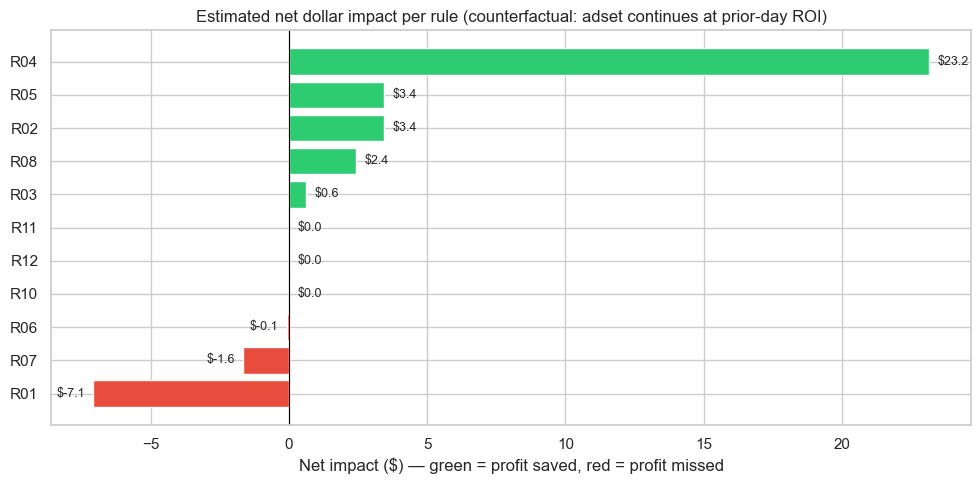

Saved: Task A/rule_impact.png


In [17]:
# --- VISUALISATION: Net impact by rule ---
fig, ax = plt.subplots(figsize=(10, 5))

rs = rule_summary.sort_values('net_impact')

bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in rs['net_impact']]
bars = ax.barh(rs['rule_id'], rs['net_impact'], color=bar_colors, edgecolor='white')

# Label each bar with the dollar value
for bar, val in zip(bars, rs['net_impact']):
    x = bar.get_width()
    ha = 'left' if x >= 0 else 'right'
    offset = 0.3 if x >= 0 else -0.3
    ax.text(x + offset, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}', va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Net impact ($) — green = profit saved, red = profit missed')
ax.set_title('Estimated net dollar impact per rule (counterfactual: adset continues at prior-day ROI)')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/Task A/rule_impact.png', dpi=150)
plt.show()
print('Saved: Task A/rule_impact.png')

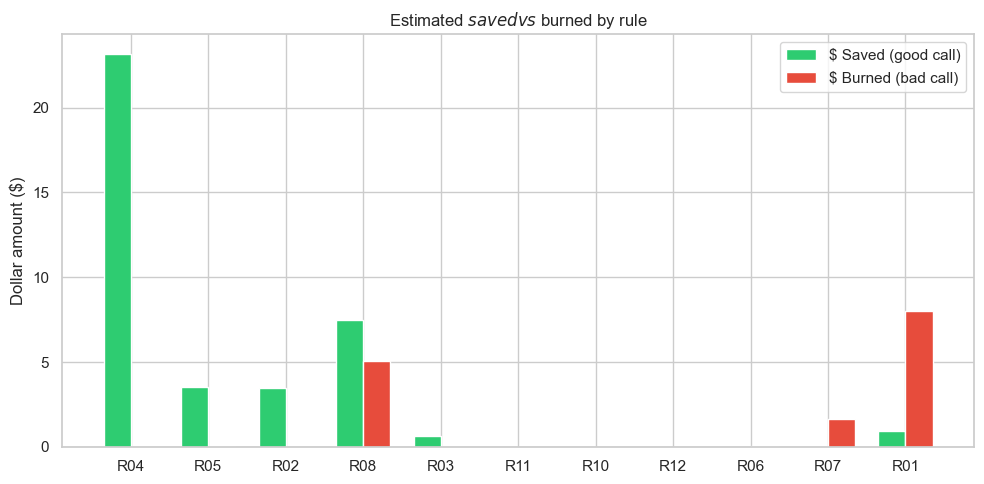

Saved: Task A/rule_saved_vs_burned.png


In [18]:
# --- VISUALISATION: Saved vs Burned side-by-side per rule ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(rule_summary))
width = 0.35

ax.bar(x - width/2, rule_summary['total_saved'], width, label='$ Saved (good call)', color='#2ecc71')
ax.bar(x + width/2, rule_summary['total_burned'], width, label='$ Burned (bad call)', color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(rule_summary['rule_id'])
ax.set_ylabel('Dollar amount ($)')
ax.set_title('Estimated $ saved vs $ burned by rule')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/Task A/rule_saved_vs_burned.png', dpi=150)
plt.show()
print('Saved: Task A/rule_saved_vs_burned.png')

---
## Section 2 — A3: Bad Decisions
Three types of decisions a human buyer would not have made.

In [19]:
# --- FLAG TYPE 1: Turn OFF when last_3_days_roi > 0 but today_roi_at_action < 0 ---
#
# Interpretation: the adset was profitable over the last 3 days,
# but today looks bad — likely because today's revenue hasn't fully arrived yet
# (revenue delay). The rule reacted to an incomplete picture.

bad_type1 = turnoff[
    (turnoff['last_3_days_roi_at_action'] > 0) &
    (turnoff['today_roi_at_action'] < 0)
].copy()

print(f'Type 1 bad decisions (profitable trend, bad today): {len(bad_type1)}')
print('\nDetails:')
cols = ['adset_id', 'action_date', 'action_time', 'rule_id',
        'today_roi_at_action', 'last_3_days_roi_at_action', 'spend', 'counterfactual_profit']
print(bad_type1[cols].to_string(index=False))

Type 1 bad decisions (profitable trend, bad today): 7

Details:
      adset_id action_date               action_time rule_id  today_roi_at_action  last_3_days_roi_at_action  spend  counterfactual_profit
31861074850791  2026-06-06 2026-06-06 03:30:17+00:00     R08              -0.3210                       0.09 1.0287              -0.330213
31196781349398  2026-06-06 2026-06-06 04:30:09+00:00     R08              -0.7488                       0.26 5.4102              -4.051158
31239079753080  2026-06-06 2026-06-06 10:30:08+00:00     R08              -1.0000                       0.20 1.2446              -1.244600
31142523663741  2026-06-06 2026-06-06 17:30:08+00:00     R05              -1.0000                       0.09 2.3241              -2.324100
31554978465845  2026-06-10 2026-06-10 15:00:12+00:00     R08              -0.8995                       0.22 4.6736              -1.130076
31818629447720  2026-06-11 2026-06-11 09:30:07+00:00     R06              -0.3429                     

In [20]:
# --- FLAG TYPE 2: Turn OFF on adset's 1st or 2nd spend day ---
#
# Interpretation: the rule had almost no data to work with.
# 1-2 days of spend is statistically meaningless for ROI judgements.

bad_type2 = turnoff[
    turnoff['total_days_at_action'] <= 2
].copy()

print(f'Type 2 bad decisions (turned off on day 1 or 2): {len(bad_type2)}')
print('\nDetails:')
cols2 = ['adset_id', 'action_date', 'action_time', 'rule_id',
         'total_days_at_action', 'today_roi_at_action', 'spend', 'counterfactual_profit']
print(bad_type2[cols2].sort_values('total_days_at_action').to_string(index=False))

Type 2 bad decisions (turned off on day 1 or 2): 45

Details:
      adset_id action_date               action_time rule_id  total_days_at_action  today_roi_at_action  spend  counterfactual_profit
31515347886140  2026-06-07 2026-06-07 08:30:09+00:00     R04                     1              -1.0000 0.9144              -0.914400
31442020869055  2026-06-07 2026-06-07 09:30:10+00:00     R04                     1              -1.0000 0.5207              -0.520700
31311598193429  2026-06-07 2026-06-07 09:30:10+00:00     R04                     1              -1.0000 0.5715              -0.571500
31983969453004  2026-06-07 2026-06-07 11:30:09+00:00     R04                     1              -1.0000 0.6096              -0.609600
31109557363427  2026-06-07 2026-06-07 13:30:16+00:00     R04                     1              -1.0000 0.6477              -0.647700
31221718773016  2026-06-07 2026-06-07 13:30:16+00:00     R04                     1              -0.9608 0.6477              -0.622310


In [21]:
# --- FLAG TYPE 3: Budget decreased 2+ times for same adset on same day (cascade) ---
#
# Interpretation: because rules fire every 30 min, a budget decrease may compound —
# first cut takes it from $200 -> $120, then the NEXT firing sees $120
# and cuts again to $72. This compounding was never intended.

# Count successful budget decrease firings per adset per day (use full execs, not deduped)
budget_fires = (
    execs[
        (execs['api_success']) &
        (execs['action_type'].apply(lambda n:
            'DECREASE' in str(n).upper() if pd.notna(n) else False))
    ]
)
# Re-derive action_type on full execs
budget_fires = execs[
    (execs['api_success']) &
    (execs['action_name'].str.upper().str.contains('DECREASE', na=False))
].copy()

cascade = (
    budget_fires.groupby(['adset_id', 'action_date'])
    .agg(
        fires=('rule_id', 'count'),
        rules_fired=('rule_id', lambda x: list(x)),
        budget_start=('old_budget', 'first'),
        budget_end=('new_budget', 'last')
    )
    .reset_index()
)
cascade = cascade[cascade['fires'] >= 2].copy()
cascade['total_cut_pct'] = ((cascade['budget_start'] - cascade['budget_end']) / cascade['budget_start']).round(3)

print(f'Type 3 bad decisions (cascade budget cuts — 2+ decreases same adset same day): {len(cascade)}')
if len(cascade) > 0:
    print(cascade.to_string(index=False))
else:
    print('No cascade events found (deduplication may have caught these).')

Type 3 bad decisions (cascade budget cuts — 2+ decreases same adset same day): 0
No cascade events found (deduplication may have caught these).


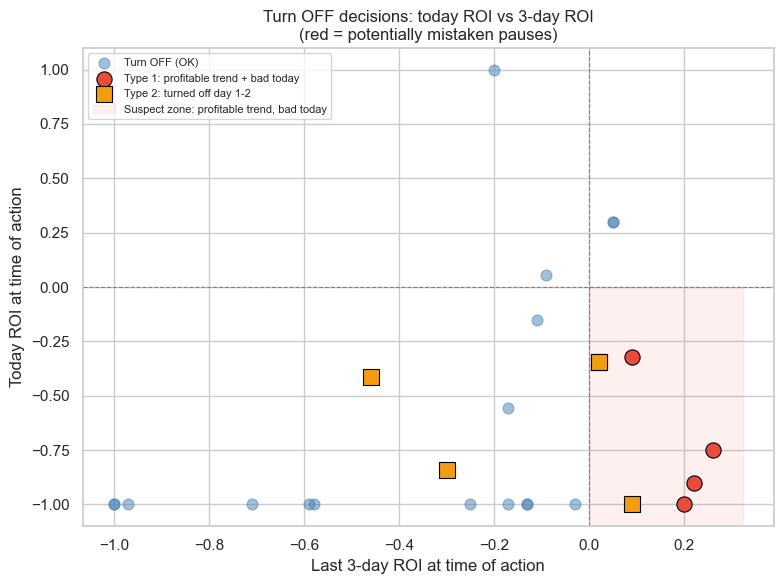

Saved: Task A/bad_decisions_scatter.png


In [22]:
# --- VISUALISATION: today_roi vs last_3_days_roi scatter, highlighting bad decisions ---
fig, ax = plt.subplots(figsize=(8, 6))

# All Turn OFF actions
ax.scatter(
    turnoff['last_3_days_roi_at_action'],
    turnoff['today_roi_at_action'],
    color='steelblue', alpha=0.5, label='Turn OFF (OK)', s=60, zorder=2
)

# Type 1 bad decisions highlighted
if len(bad_type1) > 0:
    ax.scatter(
        bad_type1['last_3_days_roi_at_action'],
        bad_type1['today_roi_at_action'],
        color='#e74c3c', s=120, zorder=3, label='Type 1: profitable trend + bad today',
        edgecolors='black', linewidths=0.8
    )

# Type 2 bad decisions highlighted  
if len(bad_type2) > 0:
    ax.scatter(
        bad_type2['last_3_days_roi_at_action'],
        bad_type2['today_roi_at_action'],
        color='#f39c12', s=120, zorder=3, label='Type 2: turned off day 1-2',
        edgecolors='black', linewidths=0.8, marker='s'
    )

# Reference lines
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

# Shade the "danger quadrant": positive 3-day ROI, negative today = suspect
ax.axvspan(0, ax.get_xlim()[1] if ax.get_xlim()[1] > 0 else 1,
           ymin=0, ymax=0.5, alpha=0.06, color='red',
           label='Suspect zone: profitable trend, bad today')

ax.set_xlabel('Last 3-day ROI at time of action')
ax.set_ylabel('Today ROI at time of action')
ax.set_title('Turn OFF decisions: today ROI vs 3-day ROI\n(red = potentially mistaken pauses)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/Task A/bad_decisions_scatter.png', dpi=150)
plt.show()
print('Saved: Task A/bad_decisions_scatter.png')

---
## Section 3 — A4: Revenue Delay
How long does it take for reported revenue to fully arrive after spend? We compare `estimated_conversions` (our prediction) vs `fb_conversions` (Facebook's reported final count) by `spend_day_no`.

In [23]:
# --- Revenue delay: estimated vs reported conversions by spend day number ---
#
# spend_day_no = how many days this adset has been spending (1 = first day).
# On day 1, revenue may not have been attributed yet.
# By day 5+, revenue should be fully settled.
#
# We only look at rows with spend > 0 (zero-spend rows have no conversions).

active = perf[perf['spend'] > 0].copy()

# Ratio of fb_conversions / estimated_conversions
# 1.0 = fully arrived. <1.0 = still arriving. >1.0 = over-estimated or late bonuses.
active['conv_ratio'] = np.where(
    active['estimated_conversions'] > 0,
    active['fb_conversions'] / active['estimated_conversions'],
    np.nan
)

delay_by_day = (
    active.groupby('spend_day_no')
    .agg(
        n_adsets=('adset_id', 'nunique'),
        mean_estimated=('estimated_conversions', 'mean'),
        mean_fb=('fb_conversions', 'mean'),
        mean_conv_ratio=('conv_ratio', 'mean'),
        mean_roi=('roi', 'mean'),
        std_roi=('roi', 'std')
    )
    .reset_index()
)

print('Revenue delay by spend_day_no:')
print(delay_by_day.to_string(index=False, float_format='{:.3f}'.format))

Revenue delay by spend_day_no:
 spend_day_no  n_adsets  mean_estimated  mean_fb  mean_conv_ratio  mean_roi  std_roi
            0         1          71.000   64.000            0.901     0.620      NaN
            1       823           2.540    2.270            0.967    -0.272    1.350
            2       401           5.501    4.956            0.963    -0.225    0.866
            3       189           8.401    7.777            0.964    -0.151    0.777
            4       145           8.698    7.993            0.959    -0.245    0.647
            5        89          14.667   13.967            0.962    -0.033    0.760
            6        53          17.655   16.545            0.945    -0.003    0.656
            7        39          16.487   15.564            0.944    -0.070    0.587
            8        32          20.206   18.912            0.960    -0.097    0.586
            9        30          41.033   38.633            0.958     0.292    0.611
           10        27          4

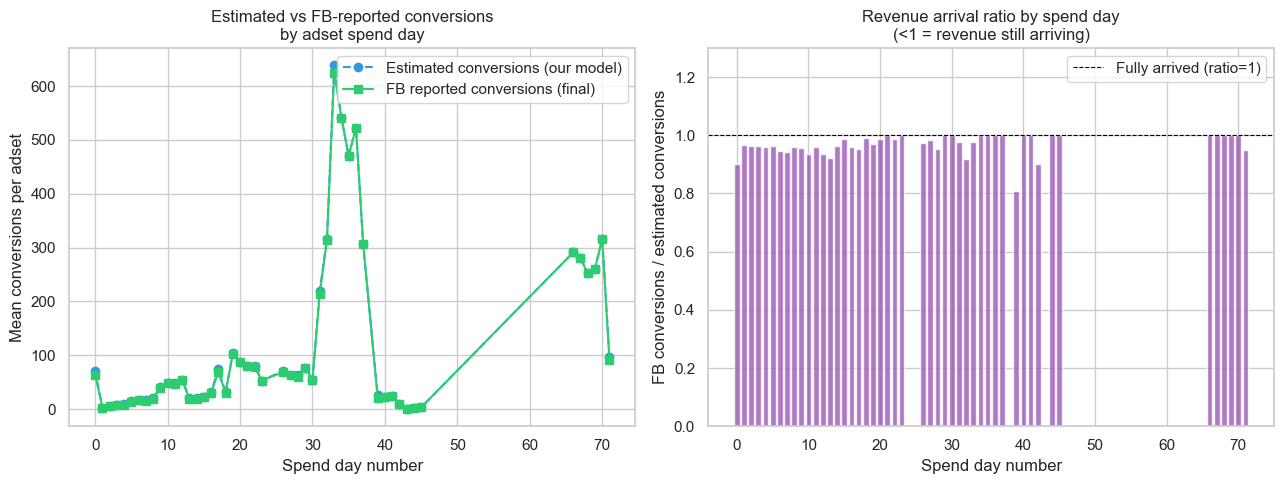

Saved: Task A/revenue_delay_conversions.png


In [24]:
# --- VISUALISATION 1: Estimated vs reported conversions by spend day ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute conversion counts
ax = axes[0]
days = delay_by_day['spend_day_no']
ax.plot(days, delay_by_day['mean_estimated'], 'o--', color='#3498db',
        label='Estimated conversions (our model)')
ax.plot(days, delay_by_day['mean_fb'], 's-', color='#2ecc71',
        label='FB reported conversions (final)')
ax.set_xlabel('Spend day number')
ax.set_ylabel('Mean conversions per adset')
ax.set_title('Estimated vs FB-reported conversions\nby adset spend day')
ax.legend()

# Right: ratio — how much of estimated is reported on each day
ax2 = axes[1]
ax2.bar(days, delay_by_day['mean_conv_ratio'], color='#9b59b6', alpha=0.8)
ax2.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='Fully arrived (ratio=1)')
ax2.set_xlabel('Spend day number')
ax2.set_ylabel('FB conversions / estimated conversions')
ax2.set_title('Revenue arrival ratio by spend day\n(<1 = revenue still arriving)')
ax2.legend()
ax2.set_ylim(0, max(delay_by_day['mean_conv_ratio'].max() * 1.2, 1.3))

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/Task A/revenue_delay_conversions.png', dpi=150)
plt.show()
print('Saved: Task A/revenue_delay_conversions.png')

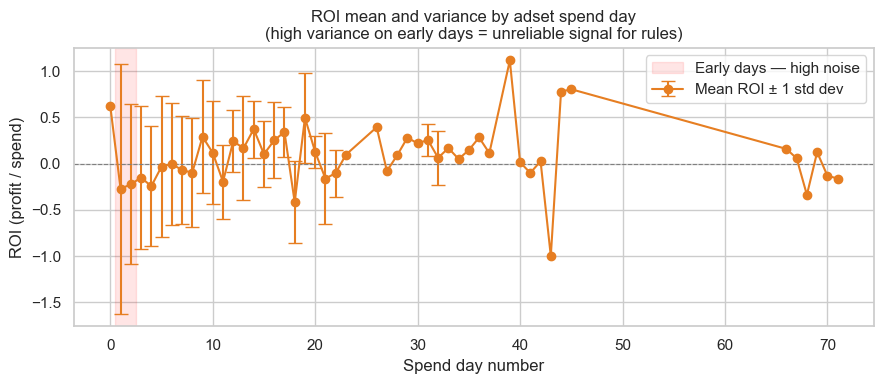

Saved: Task A/roi_stability_by_day.png


In [25]:
# --- VISUALISATION 2: ROI stability by spend day ---
# Young adsets have high ROI variance = noisy signal = bad time to make decisions.

fig, ax = plt.subplots(figsize=(9, 4))

# ROI mean ± std error bars
ax.errorbar(
    delay_by_day['spend_day_no'],
    delay_by_day['mean_roi'],
    yerr=delay_by_day['std_roi'],
    fmt='o-', color='#e67e22', capsize=5, label='Mean ROI ± 1 std dev'
)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Spend day number')
ax.set_ylabel('ROI (profit / spend)')
ax.set_title('ROI mean and variance by adset spend day\n(high variance on early days = unreliable signal for rules)')
ax.legend()

# Shade days 1-2 as the "trigger-happy zone"
ax.axvspan(0.5, 2.5, alpha=0.1, color='red', label='Early days — high noise')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/Task A/roi_stability_by_day.png', dpi=150)
plt.show()
print('Saved: Task A/roi_stability_by_day.png')

In [26]:
# --- Print final A4 summary for use in INVESTIGATION.md ---
print('=== REVENUE DELAY SUMMARY ===')
for _, row in delay_by_day.iterrows():
    ratio = row['mean_conv_ratio']
    status = 'FULLY SETTLED' if ratio >= 0.95 else ('MOSTLY ARRIVED' if ratio >= 0.7 else 'STILL ARRIVING')
    print(f"Day {int(row['spend_day_no']):>2}: "
          f"est={row['mean_estimated']:.2f}  fb={row['mean_fb']:.2f}  "
          f"ratio={ratio:.2f}  [{status}]  "
          f"adsets={int(row['n_adsets'])}")

print('\n=== KEY CONCLUSION ===')
early = delay_by_day[delay_by_day['spend_day_no'] <= 2]['mean_conv_ratio'].mean()
late = delay_by_day[delay_by_day['spend_day_no'] >= 4]['mean_conv_ratio'].mean()
print(f'Days 1-2 avg conversion ratio: {early:.2f} — rules fired on these days see incomplete revenue')
print(f'Days 4+  avg conversion ratio: {late:.2f} — revenue has substantially settled')

=== REVENUE DELAY SUMMARY ===
Day  0: est=71.00  fb=64.00  ratio=0.90  [MOSTLY ARRIVED]  adsets=1
Day  1: est=2.54  fb=2.27  ratio=0.97  [FULLY SETTLED]  adsets=823
Day  2: est=5.50  fb=4.96  ratio=0.96  [FULLY SETTLED]  adsets=401
Day  3: est=8.40  fb=7.78  ratio=0.96  [FULLY SETTLED]  adsets=189
Day  4: est=8.70  fb=7.99  ratio=0.96  [FULLY SETTLED]  adsets=145
Day  5: est=14.67  fb=13.97  ratio=0.96  [FULLY SETTLED]  adsets=89
Day  6: est=17.65  fb=16.55  ratio=0.95  [MOSTLY ARRIVED]  adsets=53
Day  7: est=16.49  fb=15.56  ratio=0.94  [MOSTLY ARRIVED]  adsets=39
Day  8: est=20.21  fb=18.91  ratio=0.96  [FULLY SETTLED]  adsets=32
Day  9: est=41.03  fb=38.63  ratio=0.96  [FULLY SETTLED]  adsets=30
Day 10: est=49.30  fb=47.81  ratio=0.94  [MOSTLY ARRIVED]  adsets=27
Day 11: est=47.94  fb=46.65  ratio=0.96  [FULLY SETTLED]  adsets=17
Day 12: est=54.78  fb=53.22  ratio=0.93  [MOSTLY ARRIVED]  adsets=9
Day 13: est=21.00  fb=19.60  ratio=0.92  [MOSTLY ARRIVED]  adsets=5
Day 14: est=20.80  